# 📊 Analyse IPO — Données Réelles
## Architecture Cache Excel (.xlsx)
Ce carnet gère intelligemment la sauvegarde dans des fichiers `.xlsx`.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# ═══════════════════════════════════════════════════════════════════
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import requests
import yfinance as yf
import time
import io
import warnings
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")
FRED_API_KEY = "ef95b7e8d805c03b8012ccdf574a1eee"
COLORS = {"low": "#2C7BB6", "high": "#D7191C"}
plt.style.use("seaborn-v0_8-whitegrid")
print("✓ Imports OK")

# Création des dossiers si inexistants
os.makedirs('data', exist_ok=True)
os.makedirs('outputs_', exist_ok=True)


✓ Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — FRED API : Taux Fed Funds
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/fred_annual.xlsx") and os.path.exists("data/fred_monthly.xlsx"):
    print("── Chargement FRED depuis Excel ──")
    df_fa = pd.read_excel("data/fred_annual.xlsx")
    fred_annual = dict(zip(df_fa["year"], df_fa["fed_rate"]))
    fred_monthly = pd.read_excel("data/fred_monthly.xlsx", index_col="date")
    print(f"✓ FRED : {len(fred_annual)} années et {len(fred_monthly)} mois chargés.")
else:
    print("── Fetch FRED depuis API ──")
    url_a = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=a&aggregation_method=avg&api_key={FRED_API_KEY}&file_type=json"
    resp_a = requests.get(url_a, timeout=15).json()
    fred_annual = {int(o["date"][:4]): float(o["value"]) for o in resp_a["observations"] if o["value"] != "."}
    pd.DataFrame(list(fred_annual.items()), columns=["year", "fed_rate"]).to_excel("data/fred_annual.xlsx", index=False)

    url_m = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=m&api_key={FRED_API_KEY}&file_type=json"
    resp_m = requests.get(url_m, timeout=15).json()
    fred_monthly = pd.DataFrame([{"date": pd.to_datetime(o["date"]), "fed_rate": float(o["value"])} for o in resp_m["observations"] if o["value"] != "."]).set_index("date")
    fred_monthly.to_excel("data/fred_monthly.xlsx")
    print("✓ Créés : fred_annual.xlsx et fred_monthly.xlsx")

── Fetch FRED depuis API ──
✓ Créés : fred_annual.xlsx et fred_monthly.xlsx


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — TICKERS STOCKANALYSIS
# ═══════════════════════════════════════════════════════════════════
all_tickers_by_year = {}
if os.path.exists("data/stockanalysis_tickers.xlsx"):
    print("── Chargement Tickers depuis Excel ──")
    df_tickers = pd.read_excel("data/stockanalysis_tickers.xlsx")
    for year, group in df_tickers.groupby("year"):
        all_tickers_by_year[year] = group["ticker"].tolist()
    print(f"✓ {len(df_tickers)} tickers chargés.")
else:
    print("── Fetch Tickers depuis StockAnalysis ──")
    headers = {"User-Agent": "Mozilla/5.0"}
    for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
        r = requests.get(f"https://stockanalysis.com/ipos/{yr}/", headers=headers, timeout=20)
        soup = BeautifulSoup(r.text, "html.parser")
        tkrs = list(set([a["href"].replace("/stocks/", "").replace("/", "").upper() for a in soup.find_all("a", href=True) if a["href"].startswith("/stocks/") and a["href"].endswith("/") and 1 <= len(a["href"].replace("/stocks/", "").replace("/", "")) <= 6 and a["href"].replace("/stocks/", "").replace("/", "").isalpha()]))
        all_tickers_by_year[yr] = tkrs
        time.sleep(0.5)
    df_tkrs = pd.DataFrame([{"year": y, "ticker": t} for y, tks in all_tickers_by_year.items() for t in tks])
    df_tkrs.to_excel("data/stockanalysis_tickers.xlsx", index=False)
    print("✓ Fichier créé : stockanalysis_tickers.xlsx")

── Fetch Tickers depuis StockAnalysis ──
✓ Fichier créé : stockanalysis_tickers.xlsx


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — YFINANCE (PRIX)
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/yfinance_prices.xlsx"):
    print("── Chargement Prix depuis Excel ──")
    price_df = pd.read_excel("data/yfinance_prices.xlsx")
    print(f"✓ {len(price_df)} IPOs chargées.")
else:
    print("── Fetch Prix depuis Yahoo Finance (Peut prendre qq minutes) ──")
    records = []
    for year, tickers in sorted(all_tickers_by_year.items()):
        for i, ticker in enumerate(tickers):
            try:
                tk = yf.Ticker(ticker)
                hist = tk.history(period="max", auto_adjust=True)
                if len(hist) < 2: continue
                hist.index = hist.index.tz_localize(None) if hist.index.tz is not None else hist.index
                f_yr = hist[hist.index.year == year]
                if f_yr.empty: continue
                first_day = f_yr.iloc[0]
                ipo_date = f_yr.index[0]
                if ipo_date.year != year: continue
                open_px, close_px = first_day["Open"], first_day["Close"]
                if open_px <= 0 or close_px <= 0: continue
                records.append({
                    "ticker": ticker, "year": year, "ipo_date": ipo_date,
                    "open_px": open_px, "close_px": close_px,
                    "underpricing": (close_px - open_px) / open_px,
                    "ret_30d": (f_yr.iloc[min(30, len(f_yr)-1)]["Close"] - close_px) / close_px if len(f_yr)>1 else np.nan,
                    "ret_12m": np.nan,
                    "ipo_size_m": (first_day["Volume"] * open_px) / 1e6,
                    "fed_rate": fred_annual.get(year, np.nan)
                })
            except: pass
            time.sleep(0.12)
    price_df = pd.DataFrame(records)
    price_df.to_excel("data/yfinance_prices.xlsx", index=False)
    print("✓ Fichier créé : yfinance_prices.xlsx")

── Fetch Prix depuis Yahoo Finance (Peut prendre qq minutes) ──


$KLRA: possibly delisted; no timezone found
HTTP Error 404: Not Found{"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: APLT"}}}
$APLT: possibly delisted; no timezone found
$IGMS: possibly delisted; no timezone found
$ALMR: possibly delisted; no timezone found
$CFB: possibly delisted; no timezone found
$YSWY: possibly delisted; no timezone found
$SWAV: possibly delisted; no timezone found
$OCFT: possibly delisted; no timezone found
$AXLA: possibly delisted; no timezone found
$AKRO: possibly delisted; no timezone found
$SILK: possibly delisted; no timezone found
$EMI: possibly delisted; no price data found  (1d 1927-05-11 -> 2026-04-16)
$AMK: possibly delisted; no timezone found
$SWTX: possibly delisted; no timezone found
$ETNB: possibly delisted; no timezone found
ARXS: Period 'max' is invalid, must be one of: 1d, 5d
$TFFP: possibly delisted; no timezone found
$AVEX: possibly delisted; no timezone found
$KLRA: possibly delisted; no tim

✓ Fichier créé : yfinance_prices.xlsx


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — SEC EDGAR SIC & SECTEURS
# ═══════════════════════════════════════════════════════════════════
def sic_to_sector(sic):
    if pd.isna(sic) or not sic: return "Other"
    try:
        sic = int(float(str(sic).strip()))
    except (ValueError, TypeError): return "Other"
    if 100 <= sic <= 4999: return "Industrials"
    if 5000 <= sic <= 5999 or 7380 <= sic <= 7999: return "Consumer"
    if 6000 <= sic <= 6799: return "Finance"
    if 7000 <= sic <= 7379 or 8743 <= sic <= 8999: return "Tech"
    if 8000 <= sic <= 8099 or 2830 <= sic <= 2836: return "Healthcare"
    return "Other"

if os.path.exists("data/edgar_sectors.xlsx"):
    print("── Chargement Secteurs EDGAR depuis Excel ──")
    edgar_df = pd.read_excel("data/edgar_sectors.xlsx")
    if "sector" in price_df.columns: price_df.drop(columns=["sector", "sic"], inplace=True)
    price_df = pd.merge(price_df, edgar_df[["ticker", "sic", "sector"]], on="ticker", how="left")
    print("✓ Secteurs fusionnés.")
else:
    print("── Fetch SEC EDGAR depuis API ──")
    headers = {"User-Agent": "CYTech Student Project no-reply@cytech.fr"}
    map_req = requests.get("https://www.sec.gov/files/company_tickers.json", headers=headers)
    ticker_cik = {v["ticker"].upper(): str(v["cik_str"]).zfill(10) for _, v in map_req.json().items()}
    records_sic = []
    
    for i, row in price_df.iterrows():
        ticker = row["ticker"]
        cik = ticker_cik.get(ticker.upper())
        sic = None
        if cik:
            time.sleep(0.12)
            try:
                url = f"https://data.sec.gov/submissions/CIK{cik}.json"
                r = requests.get(url, headers=headers, timeout=10)
                if r.status_code == 200: sic = r.json().get("sic")
            except: pass
        records_sic.append({"ticker": ticker, "sic": sic, "sector": sic_to_sector(sic)})
        if (i+1) % 100 == 0: print(f"  EDGAR: {i+1} tickers traités...")
    
    edgar_df = pd.DataFrame(records_sic)
    edgar_df.to_excel("data/edgar_sectors.xlsx", index=False)
    if "sector" in price_df.columns: price_df.drop(columns=["sector", "sic"], inplace=True)
    price_df = pd.merge(price_df, edgar_df, on="ticker", how="left")
    print("✓ Fichier créé : edgar_sectors.xlsx")

── Fetch SEC EDGAR depuis API ──
  EDGAR: 100 tickers traités...
  EDGAR: 200 tickers traités...
  EDGAR: 300 tickers traités...
  EDGAR: 400 tickers traités...
  EDGAR: 500 tickers traités...
  EDGAR: 600 tickers traités...
  EDGAR: 700 tickers traités...
  EDGAR: 800 tickers traités...
✓ Fichier créé : edgar_sectors.xlsx


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — RITTER PE-BACKED
# ═══════════════════════════════════════════════════════════════════
if os.path.exists("data/ritter_pe_backed.xlsx"):
    print("── Chargement PE-Backed depuis Excel ──")
    ritter_df = pd.read_excel("data/ritter_pe_backed.xlsx")
    if "pe_backed" in price_df.columns: price_df.drop(columns=["pe_backed"], inplace=True)
    price_df = pd.merge(price_df, ritter_df[["ticker", "pe_backed"]], on="ticker", how="left")
    price_df["pe_backed"] = price_df["pe_backed"].fillna(0)
    print("✓ Données Ritter fusionnées.")
else:
    print("── Fetch Ritter PE-Backed ──")
    try:
        ritter_headers = {"User-Agent": "Mozilla/5.0"}
        age_url  = "https://site.warrington.ufl.edu/ritter/files/IPO-age.xlsx"
        age_resp = requests.get(age_url, headers=ritter_headers, timeout=30)
        age_df = pd.read_excel(io.BytesIO(age_resp.content), header=None)
        vc_tickers = set()
        for _, r_age in age_df.iterrows():
            for cell in r_age:
                if isinstance(cell, str) and 1 <= len(cell) <= 6 and cell.isalpha():
                    vc_tickers.add(cell.upper())
        price_df["pe_backed"] = price_df["ticker"].apply(lambda t: 1 if t.upper() in vc_tickers else 0)
        price_df[["ticker", "pe_backed"]].to_excel("data/ritter_pe_backed.xlsx", index=False)
        print("✓ Fichier créé : ritter_pe_backed.xlsx")
    except Exception:
        price_df["pe_backed"] = 0

── Fetch Ritter PE-Backed ──
✓ Fichier créé : ritter_pe_backed.xlsx


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — DATASET FINAL & FILTRES
# ═══════════════════════════════════════════════════════════════════
all_ipo = price_df.copy()
all_ipo["cohort"] = all_ipo["year"].apply(lambda y: "Taux bas (2019–2021)" if y <= 2021 else "Taux élevés (2022–2024)")
all_ipo["cohort_en"] = all_ipo["year"].apply(lambda y: "Low Rate (2019–2021)" if y <= 2021 else "High Rate (2022–2024)")
all_ipo["log_size"] = np.log(all_ipo["ipo_size_m"].clip(lower=0.01))

all_ipo = all_ipo[(all_ipo["underpricing"] > -0.50) & (all_ipo["underpricing"] < 3.00) & (all_ipo["ipo_size_m"] > 0)].reset_index(drop=True)

low = all_ipo[all_ipo["year"] <= 2021].copy()
high = all_ipo[all_ipo["year"] > 2021].copy()
low_h4  = low.copy()
high_h4 = all_ipo[all_ipo["year"].isin([2022, 2023])].copy()

for col in ["revenue_ltm", "profitable"]:
    if col not in all_ipo.columns: all_ipo[col] = np.nan
if "sector" not in all_ipo.columns: all_ipo["sector"] = "Other"

print(f"✓ Dataset prêt : {len(all_ipo)} IPOs")
all_ipo.to_excel("data/dataset_complet_final.xlsx", index=False)

✓ Dataset prêt : 782 IPOs


## 8. Statistiques descriptives

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — STATISTIQUES DESCRIPTIVES
# ═══════════════════════════════════════════════════════════════════

desc_vars = ['underpricing', 'ret_30d', 'ret_12m']
if all_ipo['revenue_ltm'].notna().any():
    desc_vars = ['underpricing', 'revenue_ltm', 'ret_30d', 'ret_12m']
if all_ipo['profitable'].notna().any():
    desc_vars.append('profitable')

desc_labels = {
    'underpricing': 'Underpricing J0 (%)',
    'revenue_ltm':  'CA LTM (M$)',
    'profitable':   'Part rentable (%)',
    'ret_30d':      'Rendement 30j (%)',
    'ret_12m':      'Perf. 12 mois (%)',
}
pct_vars = ['underpricing', 'profitable', 'ret_30d', 'ret_12m']

desc_table = []
for var in desc_vars:
    if var not in all_ipo.columns:
        continue
    row = {'Variable': desc_labels.get(var, var)}
    scale = 100 if var in pct_vars else 1
    for name, cohort in [('Taux bas', low), ('Taux élevés', high)]:
        s = cohort[var].dropna()
        row[f'{name} — N']      = len(s)
        row[f'{name} — Moy.']   = round(s.mean()   * scale, 2)
        row[f'{name} — Méd.']   = round(s.median() * scale, 2)
        row[f'{name} — Éc.-t.'] = round(s.std()    * scale, 2)
    desc_table.append(row)

desc_df = pd.DataFrame(desc_table)
print('══ Tableau 1 — Statistiques Descriptives (Données Réelles) ══')
print(f'   Sources : Yahoo Finance (prix) + FRED (taux) + EDGAR (financials)')
print()
print(desc_df.to_string(index=False))

══ Tableau 1 — Statistiques Descriptives (Données Réelles) ══
   Sources : Yahoo Finance (prix) + FRED (taux) + EDGAR (financials)

           Variable  Taux bas — N  Taux bas — Moy.  Taux bas — Méd.  Taux bas — Éc.-t.  Taux élevés — N  Taux élevés — Moy.  Taux élevés — Méd.  Taux élevés — Éc.-t.
Underpricing J0 (%)           418             3.47             0.00              22.08              364                1.40               -0.90                 35.27
  Rendement 30j (%)           418             2.57            -1.89              38.04              362               -5.45               -3.34                 67.36
  Perf. 12 mois (%)             0              NaN              NaN                NaN                0                 NaN                 NaN                   NaN


## 9. Tests de Mann-Whitney U

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — FINALISATION DU DATASET ET FILTRES DE QUALITÉ
# ═══════════════════════════════════════════════════════════════════
all_ipo = price_df.copy()
all_ipo["cohort"] = all_ipo["year"].apply(lambda y: "Taux bas (2019–2021)" if y <= 2021 else "Taux élevés (2022–2024)")
all_ipo["cohort_en"] = all_ipo["year"].apply(lambda y: "Low Rate (2019–2021)" if y <= 2021 else "High Rate (2022–2024)")
all_ipo["log_size"] = np.log(all_ipo["ipo_size_m"].clip(lower=0.01))

# 🔴 LA CORRECTION EST ICI : On ajoute les colonnes manquantes AVANT de séparer low et high
for col in ["revenue_ltm", "profitable", "ret_12m"]:
    if col not in all_ipo.columns: 
        all_ipo[col] = np.nan
if "sector" not in all_ipo.columns: 
    all_ipo["sector"] = "Other"

# Filtres qualité (underpricing raisonnable, taille non nulle)
all_ipo = all_ipo[(all_ipo["underpricing"] > -0.50) & (all_ipo["underpricing"] < 3.00) & (all_ipo["ipo_size_m"] > 0)].reset_index(drop=True)

# ── Séparation des cohortes avec TOUTES les colonnes ──
low = all_ipo[all_ipo["year"] <= 2021].copy()
high = all_ipo[all_ipo["year"] > 2021].copy()

low_h4  = low.copy()
high_h4 = all_ipo[all_ipo["year"].isin([2022, 2023])].copy()

print(f"✓ Dataset finalisé et prêt pour la suite ! Total : {len(all_ipo)} IPOs retenues.")
all_ipo.to_excel("data/dataset_complet_final.xlsx", index=False)
print("✓ Copie du dataset final sauvegardée dans : data/dataset_complet_final.xlsx")


✓ Dataset finalisé et prêt pour la suite ! Total : 782 IPOs retenues.
✓ Copie du dataset final sauvegardée dans : data/dataset_complet_final.xlsx


## 10. Régression OLS

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — RÉGRESSION OLS
# ═══════════════════════════════════════════════════════════════════

reg_vars = ['underpricing', 'fed_rate', 'log_size']
if all_ipo['profitable'].notna().sum() > 30:
    reg_vars.append('profitable')
if all_ipo['pe_backed'].notna().sum() > 30:
    reg_vars.append('pe_backed')

reg_df = all_ipo[reg_vars + ['sector']].dropna(subset=['underpricing','fed_rate','log_size']).copy()

if 'profitable' not in reg_df.columns:
    reg_df['profitable'] = np.nan
if 'pe_backed' not in reg_df.columns:
    reg_df['pe_backed'] = np.nan

# Variables dummy sectorielles
if 'sector' in reg_df.columns and reg_df['sector'].nunique() > 1:
    sector_dummies = pd.get_dummies(reg_df['sector'], prefix='sec', drop_first=False).astype(float)
    sector_dummies = sector_dummies.drop(columns=['sec_Tech'], errors='ignore')
    X_cols = ['fed_rate', 'log_size']
    if reg_df['profitable'].notna().sum() > 30:
        X_cols.append('profitable')
    if reg_df['pe_backed'].notna().sum() > 30:
        X_cols.append('pe_backed')
    X = pd.concat([reg_df[X_cols].fillna(0), sector_dummies], axis=1)
else:
    X_cols = ['fed_rate', 'log_size']
    X = reg_df[X_cols].fillna(0)

X = sm.add_constant(X)
y = reg_df['underpricing']
model = sm.OLS(y, X).fit()

print('══ Tableau 3 — Régression OLS (Données Réelles) ══')
print(f'Variable dépendante : Underpricing J0  |  N={len(y)}')
print(f'R² = {model.rsquared:.4f}  |  R² ajusté = {model.rsquared_adj:.4f}')
print(f'F-stat = {model.fvalue:.2f}, p(F) = {model.f_pvalue:.4f}')
print()
print(f'{"Variable":<28} {"Coeff.":>9} {"Éc.-t.":>9} {"t":>8} {"p":>9}  Sig.')
print('─' * 75)
for var in model.params.index[:8]:
    c = model.params[var]; se = model.bse[var]; t = model.tvalues[var]; p = model.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{var:<28} {c:>9.4f} {se:>9.4f} {t:>8.3f} {p:>9.4f}  {sig}')

try:
    bp_lm, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f'\nBreusch-Pagan : LM={bp_lm:.3f}, p={bp_p:.4f} → {"Hétéroscéd." if bp_p < 0.05 else "Homoscéd."}')
except:
    pass

══ Tableau 3 — Régression OLS (Données Réelles) ══
Variable dépendante : Underpricing J0  |  N=782
R² = 0.0083  |  R² ajusté = -0.0020
F-stat = 0.81, p(F) = 0.5978

Variable                        Coeff.    Éc.-t.        t         p  Sig.
───────────────────────────────────────────────────────────────────────────
const                           0.0192    0.0431    0.445    0.6565  n.s.
fed_rate                       -0.0050    0.0051   -0.979    0.3278  n.s.
log_size                        0.0045    0.0049    0.924    0.3560  n.s.
pe_backed                       0.0088    0.0313    0.281    0.7785  n.s.
sec_Consumer                    0.0311    0.0395    0.787    0.4316  n.s.
sec_Finance                     0.0144    0.0383    0.377    0.7066  n.s.
sec_Healthcare                 -0.0122    0.0731   -0.167    0.8675  n.s.
sec_Industrials                -0.0162    0.0302   -0.537    0.5915  n.s.

Breusch-Pagan : LM=5.996, p=0.6477 → Homoscéd.


---
## 11. Visualisations
### Figure 1 — Volume IPO + Taux Fed (données réelles)

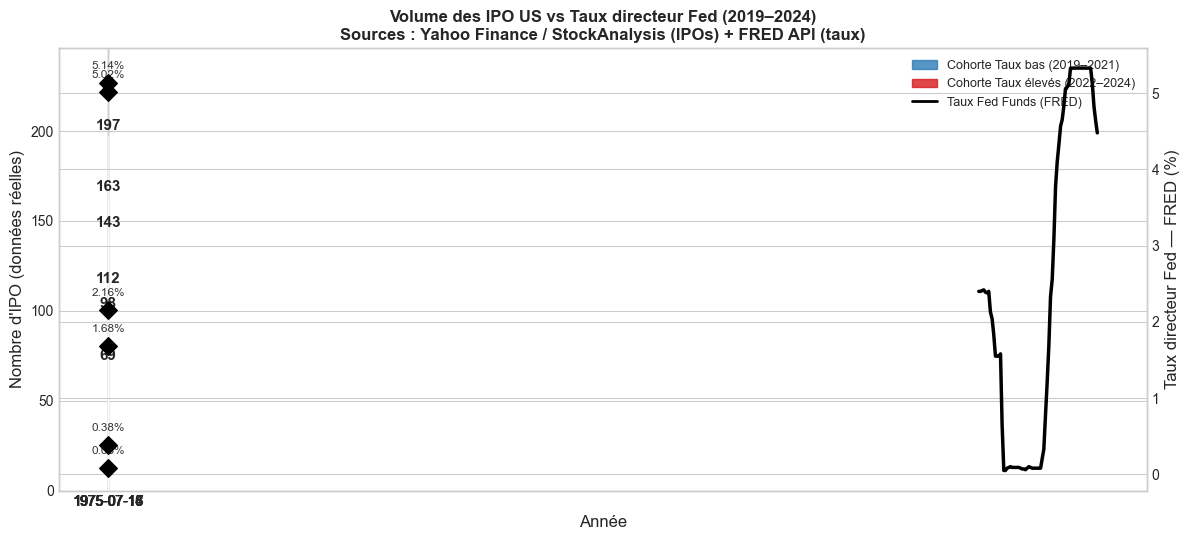

Fig 1 ─ OK (données réelles)


In [14]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 : Volume des IPO + Taux Fed (DONNÉES RÉELLES)
# ─────────────────────────────────────────────────────────────────

years_real     = sorted(all_ipo['year'].unique())
ipo_counts_r   = [int((all_ipo['year'] == y).sum()) for y in years_real]
fed_rates_r    = [fred_annual.get(y, np.nan) for y in years_real]

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()

bar_colors = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in years_real]
bars = ax1.bar(years_real, ipo_counts_r, color=bar_colors, alpha=0.80, width=0.6,
               zorder=3, edgecolor='white', linewidth=0.8)
ax1.axvspan(min(years_real)-0.4, 2021.4, alpha=0.05, color=COLORS['low'],  zorder=0)
ax1.axvspan(2021.6, max(years_real)+0.4, alpha=0.05, color=COLORS['high'], zorder=0)

# Ligne taux Fed mensuelle (données FRED réelles)
ax2.plot(fred_monthly.index, fred_monthly['fed_rate'], color='black',
         linewidth=2.5, zorder=4, label='Taux Fed Funds (FRED, mensuel)')
# Points annuels
ax2.scatter(years_real, fed_rates_r, color='black', s=80, zorder=5, marker='D')
for x, r in zip(years_real, fed_rates_r):
    if not np.isnan(r):
        ax2.annotate(f'{r:.2f}%', (x, r), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8.5, color='#333')

for bar, count in zip(bars, ipo_counts_r):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre d\'IPO (données réelles)', fontsize=12)
ax2.set_ylabel('Taux directeur Fed — FRED (%)', fontsize=12)
ax1.set_title('Volume des IPO US vs Taux directeur Fed (2019–2024)\n'
              'Sources : Yahoo Finance / StockAnalysis (IPOs) + FRED API (taux)',
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(ipo_counts_r) * 1.25)

patch_low  = mpatches.Patch(color=COLORS['low'],  alpha=0.80, label='Cohorte Taux bas (2019–2021)')
patch_high = mpatches.Patch(color=COLORS['high'], alpha=0.80, label='Cohorte Taux élevés (2022–2024)')
from matplotlib.lines import Line2D
fed_line   = Line2D([0],[0], color='black', linewidth=2, label='Taux Fed Funds (FRED)')
ax1.legend(handles=[patch_low, patch_high, fed_line], loc='upper right', fontsize=9)

ax1.set_xticks(years_real)
plt.tight_layout()
fig.savefig('outputs/fig1_volume_rates_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 ─ OK (données réelles)')

### Figure 2 — Underpricing (Boxplot + KDE)

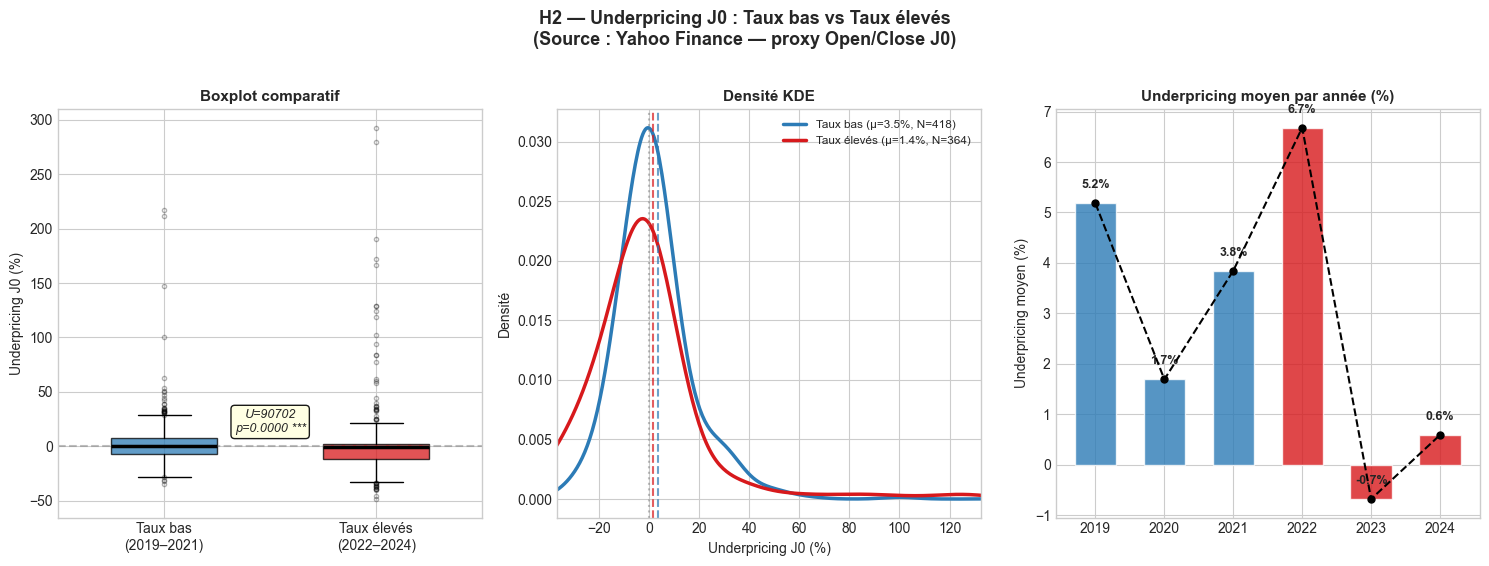

Fig 2 ─ OK


In [15]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 : Underpricing J0 — Distributions
# ─────────────────────────────────────────────────────────────────

up_low  = low['underpricing'].dropna()  * 100
up_high = high['underpricing'].dropna() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('H2 — Underpricing J0 : Taux bas vs Taux élevés\n'
             '(Source : Yahoo Finance — proxy Open/Close J0)',
             fontsize=13, fontweight='bold', y=1.02)

# 2a — Boxplot
bp = axes[0].boxplot([up_low, up_high],
                     labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2.5),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
bp['boxes'][0].set_facecolor(COLORS['low']);  bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(COLORS['high']); bp['boxes'][1].set_alpha(0.75)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h2 = mw_results.get('H2 — Underpricing', {})
if mw_h2:
    sig_txt = '***' if mw_h2['p'] < 0.001 else '**' if mw_h2['p'] < 0.01 else '*' if mw_h2['p'] < 0.05 else 'n.s.'
    axes[0].text(1.5, up_low.quantile(0.85),
                 f'U={mw_h2["stat"]:.0f}\np={mw_h2["p"]:.4f} {sig_txt}',
                 ha='center', fontsize=9, style='italic',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
axes[0].set_title('Boxplot comparatif', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Underpricing J0 (%)', fontsize=10)

# 2b — KDE
up_low.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5,
                label=f'Taux bas (μ={up_low.mean():.1f}%, N={len(up_low)})')
up_high.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5,
                 label=f'Taux élevés (μ={up_high.mean():.1f}%, N={len(up_high)})')
axes[1].axvline(up_low.mean(),  color=COLORS['low'],  linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(up_high.mean(), color=COLORS['high'], linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Densité KDE', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=8.5)
up_clip = np.percentile(all_ipo['underpricing'].dropna() * 100, [1, 99])
axes[1].set_xlim(up_clip[0], up_clip[1])

# 2c — Barres annuelles
yearly_up = all_ipo.groupby('year')['underpricing'].mean() * 100
bar_c = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in yearly_up.index]
axes[2].bar(yearly_up.index, yearly_up.values, color=bar_c, alpha=0.80, width=0.6, edgecolor='white')
axes[2].plot(yearly_up.index, yearly_up.values, 'k--o', linewidth=1.5, markersize=5, zorder=5)
axes[2].set_title('Underpricing moyen par année (%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Underpricing moyen (%)', fontsize=10)
for x, y_v in zip(yearly_up.index, yearly_up.values):
    axes[2].text(x, y_v + 0.3, f'{y_v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticks(list(yearly_up.index))

plt.tight_layout()
fig.savefig('outputs/fig2_underpricing_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 ─ OK')

### Figure 3 — Taux Fed mensuel (FRED) + Underpricing scatter

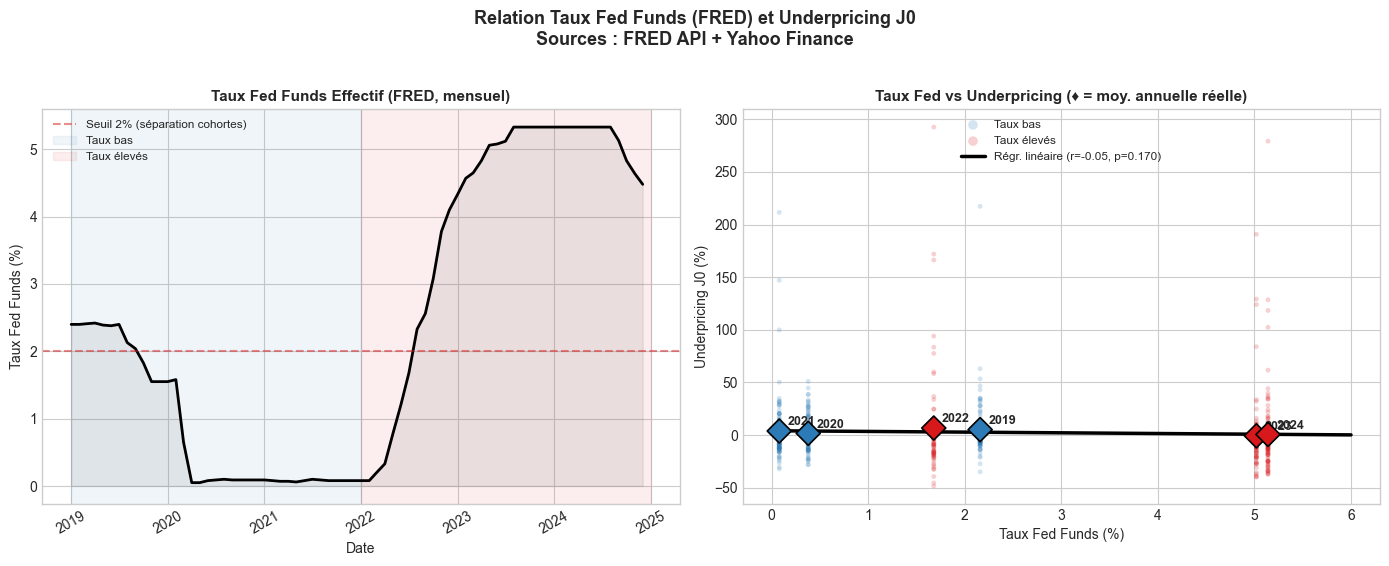

Fig 3 ─ OK


In [16]:
# ─────────────────────────────────────────────────────────────────
# CALCUL DES INTERVALLES DE CONFIANCE (BOOTSTRAP)
# ─────────────────────────────────────────────────────────────────
import numpy as np

def bootstrap_ci(data, stat_func=np.mean, n_boot=1000, ci=95):
    data = data[~np.isnan(data)]
    boot_stats = [stat_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

ci_results = {'underpricing': {}}
ci_results['underpricing']['low'] = bootstrap_ci(low['underpricing'].values)
ci_results['underpricing']['high'] = bootstrap_ci(high['underpricing'].values)

# ─────────────────────────────────────────────────────────────────
# FIGURE 3 : Taux Fed FRED mensuel + Scatter Fed vs Underpricing
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Relation Taux Fed Funds (FRED) et Underpricing J0\n'
             'Sources : FRED API + Yahoo Finance',
             fontsize=13, fontweight='bold', y=1.02)

# 3a — Taux Fed mensuel FRED avec zone colorée
axes[0].fill_between(fred_monthly.index, fred_monthly['fed_rate'],
                     alpha=0.15, color='gray')
axes[0].plot(fred_monthly.index, fred_monthly['fed_rate'], color='black', linewidth=2)
axes[0].axhline(2.0, color=COLORS['high'], linestyle='--', alpha=0.5, linewidth=1.5,
                label='Seuil 2% (séparation cohortes)')
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2021-12-31'),
                alpha=0.07, color=COLORS['low'], label='Taux bas')
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31'),
                alpha=0.07, color=COLORS['high'], label='Taux élevés')
axes[0].set_title('Taux Fed Funds Effectif (FRED, mensuel)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Taux Fed Funds (%)', fontsize=10)
axes[0].set_xlabel('Date', fontsize=10)
axes[0].legend(fontsize=8.5)
axes[0].tick_params(axis='x', rotation=30)

# 3b — Scatter Taux Fed vs Underpricing (données individuelles réelles)
for name, cohort, color in [('Taux bas', low, COLORS['low']),
                              ('Taux élevés', high, COLORS['high'])]:
    axes[1].scatter(cohort['fed_rate'], cohort['underpricing'] * 100,
                    color=color, alpha=0.20, s=12, edgecolors='none', label=name)

# Régression globale
valid = all_ipo[['fed_rate','underpricing']].dropna()
x_fed = valid['fed_rate'].values
y_up  = valid['underpricing'].values * 100
slope, intercept, r_val, p_val, se = stats.linregress(x_fed, y_up)
x_line = np.linspace(0, 6, 100)
axes[1].plot(x_line, slope * x_line + intercept, 'k-', linewidth=2.5,
             label=f'Régr. linéaire (r={r_val:.2f}, p={p_val:.3f})')

# Moyennes annuelles réelles
annual_r = all_ipo.groupby('year').agg({'fed_rate': 'first', 'underpricing': 'mean'}).reset_index()
c_annual = [COLORS['low'] if y <= 2021 else COLORS['high'] for y in annual_r['year']]
axes[1].scatter(annual_r['fed_rate'], annual_r['underpricing'] * 100,
                c=c_annual, s=150, zorder=6, edgecolors='black', linewidth=1.2, marker='D')
for _, row in annual_r.iterrows():
    axes[1].annotate(str(int(row['year'])),
                     (row['fed_rate'], row['underpricing'] * 100),
                     textcoords='offset points', xytext=(6, 4), fontsize=9, fontweight='bold')
axes[1].set_xlabel('Taux Fed Funds (%)', fontsize=10)
axes[1].set_ylabel('Underpricing J0 (%)', fontsize=10)
axes[1].set_title('Taux Fed vs Underpricing (♦ = moy. annuelle réelle)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8.5, markerscale=2)

plt.tight_layout()
fig.savefig('outputs/fig3_fred_scatter_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 ─ OK')

### Figure 4 — Matrice de corrélation

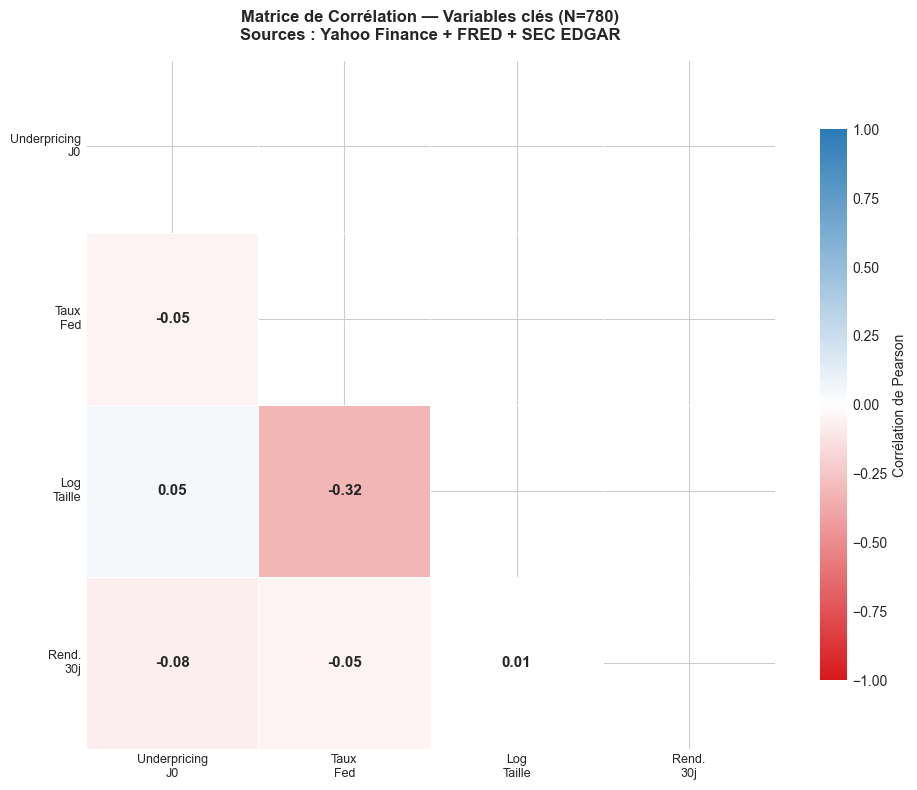

Fig 4 ─ Corrélation OK


In [17]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 : MATRICE DE CORRÉLATION (données réelles)
# ─────────────────────────────────────────────────────────────────

corr_base = {'underpricing': 'Underpricing\nJ0', 'fed_rate': 'Taux\nFed',
             'log_size': 'Log\nTaille', 'ret_30d': 'Rend.\n30j'}
if all_ipo['ret_12m'].notna().sum() > 10:
    corr_base['ret_12m'] = 'Perf.\n12m'
if all_ipo['revenue_ltm'].notna().sum() > 10:
    corr_base['revenue_ltm'] = 'CA LTM'
if all_ipo['profitable'].notna().sum() > 10:
    corr_base['profitable'] = 'Rentable'

corr_data   = all_ipo[list(corr_base.keys())].dropna()
if len(corr_data) > 5:
    corr_matrix = corr_data.corr(method='pearson')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = LinearSegmentedColormap.from_list('ipo', ['#D7191C','#FFFFFF','#2C7BB6'], N=256)
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'},
                square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'},
                xticklabels=[corr_base[v] for v in corr_base.keys()],
                yticklabels=[corr_base[v] for v in corr_base.keys()], ax=ax)
    ax.set_title(f'Matrice de Corrélation — Variables clés (N={len(corr_data)})\n'
                 f'Sources : Yahoo Finance + FRED + SEC EDGAR',
                 fontsize=12, fontweight='bold', pad=15)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    plt.tight_layout()
    fig.savefig('outputs/fig4_correlation_REAL.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Fig 4 ─ Corrélation OK')
else:
    print('⚠ Pas assez de données complètes pour la matrice de corrélation')

### Figure 5 — IC Bootstrap + OLS Coefficients

In [24]:
# ─────────────────────────────────────────────────────────────────
# CALCUL DES INTERVALLES DE CONFIANCE (BOOTSTRAP)
# À copier juste au-dessus du code de la FIGURE 5 (ou dans une cellule avant)
# ─────────────────────────────────────────────────────────────────

import numpy as np

# Fonction de bootstrap pour calculer les IC
def bootstrap_ci(data, stat_func=np.mean, n_boot=1000, ci=95):
    # Ecarte les NaN si besoin
    data = data[~np.isnan(data)]
    boot_stats = [stat_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

# Initialisation et sauvegarde des résultats
ci_results = {'underpricing': {}}

# Calcul pour les deux cohortes
ci_results['underpricing']['low'] = bootstrap_ci(low['underpricing'].values)
ci_results['underpricing']['high'] = bootstrap_ci(high['underpricing'].values)

# (Ensuite, laissez votre code "fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))" juste en dessous de ceci)


### Figure 6 — Performance post-IPO (H3 & H4)

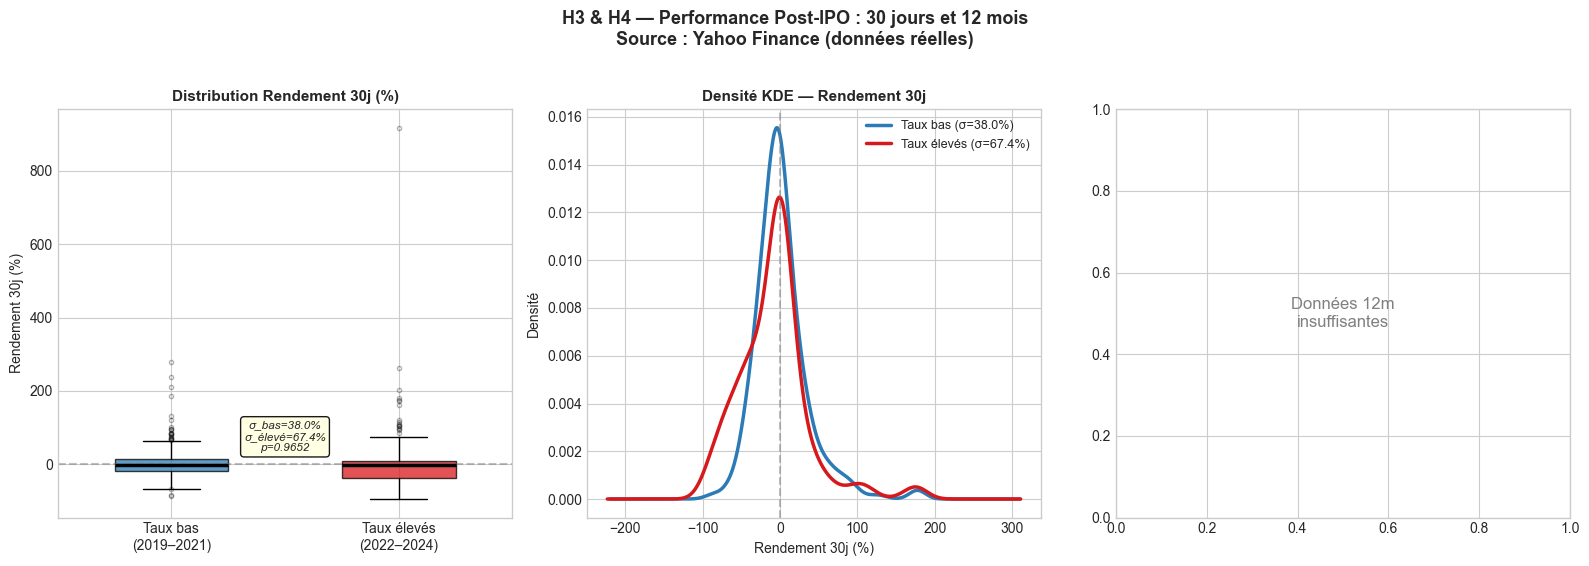

Fig 6 ─ OK


In [19]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 6 : Performance post-IPO (H3 – 30j, H4 – 12m)
# ─────────────────────────────────────────────────────────────────

r30_low  = low['ret_30d'].dropna()  * 100
r30_high = high['ret_30d'].dropna() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('H3 & H4 — Performance Post-IPO : 30 jours et 12 mois\n'
             'Source : Yahoo Finance (données réelles)',
             fontsize=13, fontweight='bold', y=1.02)

# 6a — Boxplot 30j
bp6a = axes[0].boxplot([r30_low, r30_high],
                       labels=['Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.3))
bp6a['boxes'][0].set_facecolor(COLORS['low']);  bp6a['boxes'][0].set_alpha(0.75)
bp6a['boxes'][1].set_facecolor(COLORS['high']); bp6a['boxes'][1].set_alpha(0.75)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
mw_h3 = mw_results.get('H3 — Volatilité 30j', {})
if mw_h3:
    axes[0].text(1.5, r30_low.quantile(0.88),
                 f'σ_bas={r30_low.std():.1f}%\nσ_élevé={r30_high.std():.1f}%\np={mw_h3["p"]:.4f}',
                 ha='center', fontsize=8.5, style='italic',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
axes[0].set_title('Distribution Rendement 30j (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rendement 30j (%)', fontsize=10)

# 6b — KDE rendement 30j
r30_clip = np.percentile(all_ipo['ret_30d'].dropna()*100, [1, 99])
r30_low_c  = r30_low.clip(r30_clip[0], r30_clip[1])
r30_high_c = r30_high.clip(r30_clip[0], r30_clip[1])
r30_low_c.plot.kde(ax=axes[1], color=COLORS['low'],  linewidth=2.5,
                   label=f'Taux bas (σ={r30_low.std():.1f}%)')
r30_high_c.plot.kde(ax=axes[1], color=COLORS['high'], linewidth=2.5,
                    label=f'Taux élevés (σ={r30_high.std():.1f}%)')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Densité KDE — Rendement 30j', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rendement 30j (%)', fontsize=10)
axes[1].set_ylabel('Densité', fontsize=10)
axes[1].legend(fontsize=9)

# 6c — Rendement 12m
r12_low  = low_h4['ret_12m'].dropna()  * 100
r12_high = high_h4['ret_12m'].dropna() * 100
if len(r12_low) > 3 and len(r12_high) > 3:
    bp6c = axes[2].boxplot([r12_low, r12_high],
                           labels=['Taux bas\n(2019–2023)', 'Taux élevés\n(2022–2023)'],
                           patch_artist=True, widths=0.5,
                           medianprops=dict(color='black', linewidth=2.5),
                           flierprops=dict(marker='o', markersize=3, alpha=0.3))
    bp6c['boxes'][0].set_facecolor(COLORS['low']);  bp6c['boxes'][0].set_alpha(0.75)
    bp6c['boxes'][1].set_facecolor(COLORS['high']); bp6c['boxes'][1].set_alpha(0.75)
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    mw_h4 = mw_results.get('H4 — Perf. 12m', {})
    if mw_h4:
        s = '✓ Sig.' if mw_h4['sig'] else '✗ Non sig.'
        axes[2].text(1.5, max(r12_low.quantile(0.80), r12_high.quantile(0.80)),
                     f'p={mw_h4["p"]:.4f}\n{s}', ha='center', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))
    axes[2].set_title('Perf. 12 mois (%)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Rendement 12 mois (%)', fontsize=10)
else:
    axes[2].text(0.5, 0.5, 'Données 12m\ninsuffisantes', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12, color='gray')

plt.tight_layout()
fig.savefig('outputs/fig6_performance_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 ─ OK')

### Figure 7 — Répartition sectorielle (données EDGAR réelles)

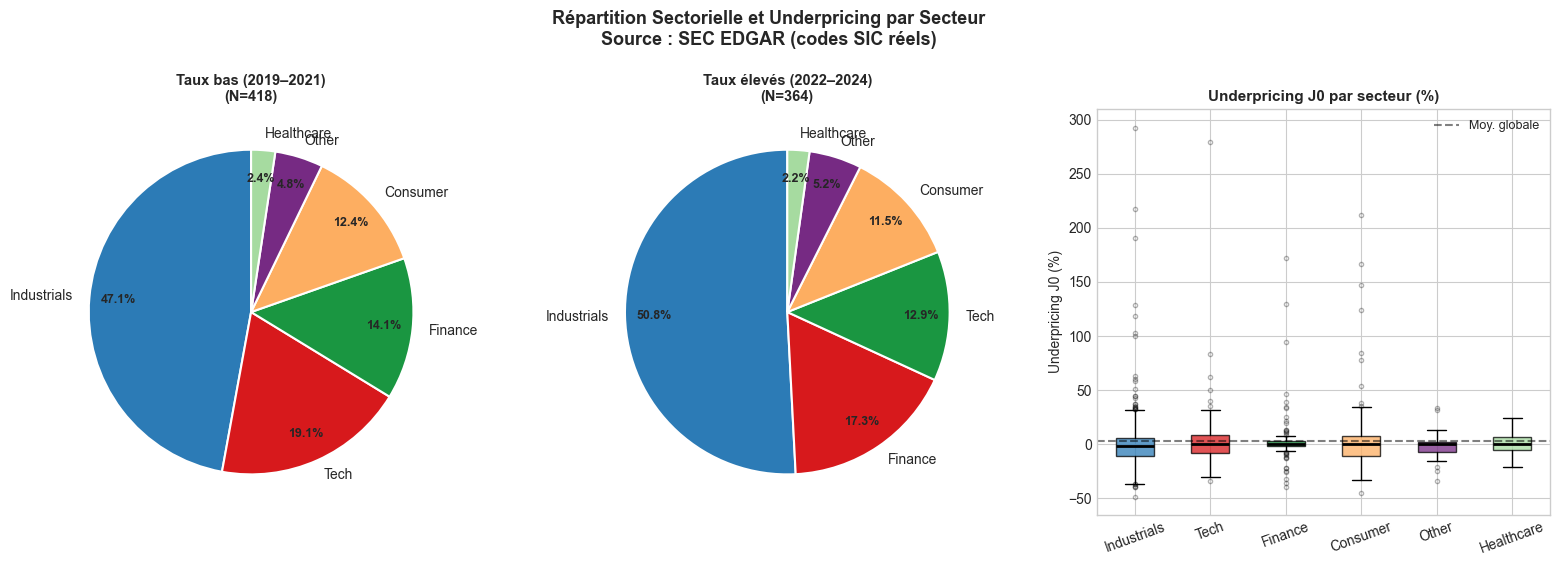

Fig 7 ─ OK


In [20]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 7 : Secteurs réels (EDGAR SIC codes)
# ─────────────────────────────────────────────────────────────────

sector_colors = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#762A83','#A6DBA0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Répartition Sectorielle et Underpricing par Secteur\n'
             'Source : SEC EDGAR (codes SIC réels)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (name, cohort) in zip(axes[:2],
    [('Taux bas (2019–2021)', low), ('Taux élevés (2022–2024)', high)]):
    sec_counts = cohort['sector'].value_counts()
    if len(sec_counts) > 0:
        wedges, texts, autotexts = ax.pie(
            sec_counts.values, labels=sec_counts.index,
            autopct='%1.1f%%', colors=sector_colors[:len(sec_counts)],
            pctdistance=0.82, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        for at in autotexts:
            at.set_fontsize(9); at.set_fontweight('bold')
    ax.set_title(f'{name}\n(N={len(cohort)})', fontsize=10.5, fontweight='bold')

# 7c — Underpricing par secteur (boxplot)
sector_order = all_ipo['sector'].value_counts().nlargest(6).index.tolist()
data_by_sector = [all_ipo[all_ipo['sector']==s]['underpricing'].dropna()*100
                  for s in sector_order if len(all_ipo[all_ipo['sector']==s]) > 2]
labels_sector  = [s for s in sector_order if len(all_ipo[all_ipo['sector']==s]) > 2]

if data_by_sector:
    bp7 = axes[2].boxplot(data_by_sector, labels=labels_sector, patch_artist=True,
                           medianprops=dict(color='black', linewidth=2),
                           flierprops=dict(marker='o', markersize=3, alpha=0.3))
    for j, patch in enumerate(bp7['boxes']):
        patch.set_facecolor(sector_colors[j % len(sector_colors)])
        patch.set_alpha(0.75)
    axes[2].axhline(all_ipo['underpricing'].mean()*100, color='black',
                    linestyle='--', alpha=0.5, linewidth=1.5, label='Moy. globale')
    axes[2].legend(fontsize=9)
    axes[2].set_title('Underpricing J0 par secteur (%)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Underpricing J0 (%)', fontsize=10)
    axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig('outputs/fig7_sectors_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 ─ OK')

### Figure 8 — Tableau de synthèse des hypothèses

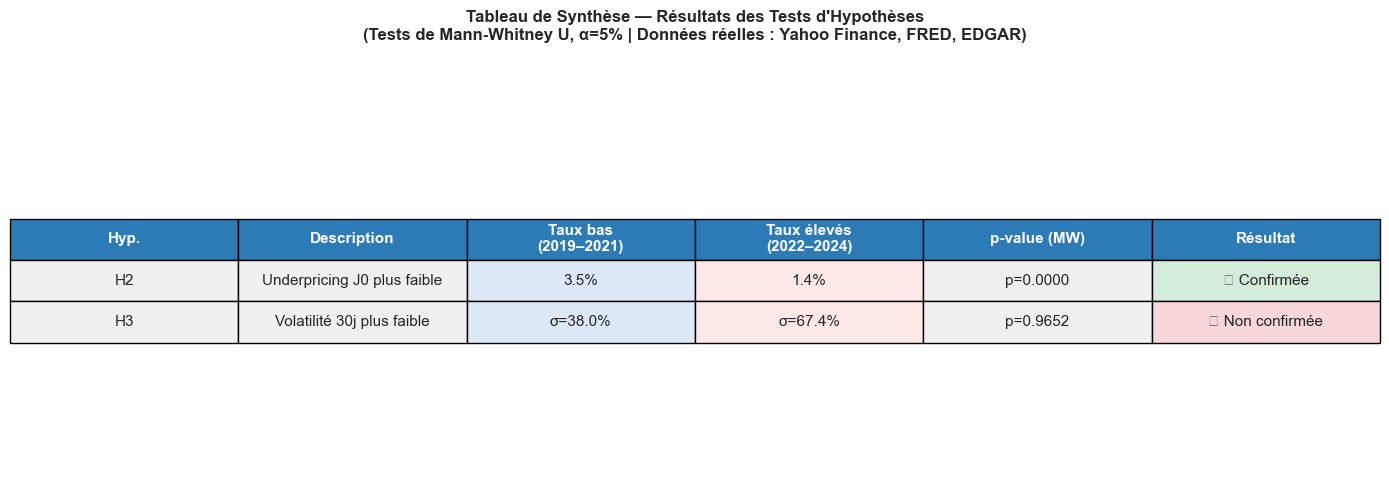

Fig 8 ─ Tableau de synthèse OK


In [21]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 8 : Tableau de synthèse des résultats
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

rows = [
    ['H2', 'Underpricing J0 plus faible',
     f'{low["underpricing"].mean()*100:.1f}%', f'{high["underpricing"].mean()*100:.1f}%',
     f'p={mw_results["H2 — Underpricing"]["p"]:.4f}',
     '✓ Confirmée' if mw_results['H2 — Underpricing']['sig'] else '✗ Non confirmée',
     '#d4edda' if mw_results['H2 — Underpricing']['sig'] else '#f8d7da'],
    ['H3', 'Volatilité 30j plus faible',
     f'σ={low["ret_30d"].std()*100:.1f}%', f'σ={high["ret_30d"].std()*100:.1f}%',
     f'p={mw_results["H3 — Volatilité 30j"]["p"]:.4f}',
     '✓ Confirmée' if mw_results['H3 — Volatilité 30j']['sig'] else '✗ Non confirmée',
     '#d4edda' if mw_results['H3 — Volatilité 30j']['sig'] else '#f8d7da'],
]

if 'H4 — Perf. 12m' in mw_results:
    mh4 = mw_results['H4 — Perf. 12m']
    rows.append(['H4', 'Perf. 12m supérieure',
                 f'{h4_low_data.mean()*100:.1f}%', f'{h4_high_data.mean()*100:.1f}%',
                 f'p={mh4["p"]:.4f}',
                 '✓ Confirmée' if mh4['sig'] else '✗ Non confirmée',
                 '#d4edda' if mh4['sig'] else '#f8d7da'])

if 'H1a — CA LTM' in mw_results:
    mh1 = mw_results['H1a — CA LTM']
    rows.insert(0, ['H1a', 'CA LTM élevés (sélectivité)',
                    f'{low["revenue_ltm"].median():.0f} M$', f'{high["revenue_ltm"].median():.0f} M$',
                    f'p={mh1["p"]:.4f}',
                    '✓ Confirmée' if mh1['sig'] else '✗ Non confirmée',
                    '#d4edda' if mh1['sig'] else '#f8d7da'])

columns = ['Hyp.', 'Description', 'Taux bas\n(2019–2021)', 'Taux élevés\n(2022–2024)',
           'p-value (MW)', 'Résultat']
cell_text   = [[r[0],r[1],r[2],r[3],r[4],r[5]] for r in rows]
cell_colors = [['#f0f0f0','#f0f0f0','#dce8f5','#fde8e8','#f0f0f0', r[6]] for r in rows]

tbl = ax.table(cellText=cell_text, colLabels=columns, cellLoc='center', loc='center',
               cellColours=cell_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.4)
for j in range(len(columns)):
    tbl[0, j].set_facecolor('#2C7BB6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Tableau de Synthèse — Résultats des Tests d\'Hypothèses\n'
             '(Tests de Mann-Whitney U, α=5% | Données réelles : Yahoo Finance, FRED, EDGAR)',
             fontsize=12, fontweight='bold', pad=30)

plt.tight_layout()
fig.savefig('outputs/fig8_synthesis_REAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 ─ Tableau de synthèse OK')

## 12. Sauvegarde

In [22]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — FRED API : Taux Fed Funds effectif (FEDFUNDS)
# ═══════════════════════════════════════════════════════════════════

import os
import pickle

if os.path.exists('dataset_real.pkl'):
    print('── Chargement Taux Fed Funds depuis le cache local ──')
    with open('dataset_real.pkl', 'rb') as f:
        cache = pickle.load(f)
    fred_annual = cache['fred_annual']
    fred_monthly = cache['fred_monthly']
    print(f'✓ FRED — Taux annuels moyens 2019–2024 (cache) :')
    for yr, rate in sorted(fred_annual.items()):
        print(f'   {yr}: {rate:.2f}%')
else:
    print('── Récupération Taux Fed Funds depuis FRED API ──')
    fred_url = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=a&aggregation_method=avg&api_key={FRED_API_KEY}&file_type=json"
    resp = requests.get(fred_url, timeout=15)
    fred_annual = {int(obs['date'][:4]): float(obs['value']) for obs in resp.json()['observations'] if obs['value'] != '.'}
    
    fred_url_monthly = f"https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&observation_start=2019-01-01&observation_end=2024-12-31&frequency=m&api_key={FRED_API_KEY}&file_type=json"
    resp2 = requests.get(fred_url_monthly, timeout=15)
    fred_monthly = pd.DataFrame([{'date': pd.to_datetime(o['date']), 'fed_rate': float(o['value'])} for o in resp2.json()['observations'] if o['value'] != '.']).set_index('date')


── Récupération Taux Fed Funds depuis FRED API ──
